# Retail Store Sales — Analyse Marketing Data
## Partie 1 : Chargement, Jointures & Construction du Schéma en Étoile

> **Objectif** : Charger les 3 fichiers bruts, construire le dataset maître par jointures, enrichir les features et générer les 5 tables du schéma en étoile pour Power BI.

---
**Auteur** : Malcom Closse — Marketing Data Analyst.   
**Dataset** : Retail Store Sales Forecasting Kaggle.  
**Stack** : Python · Pandas · PostgrSQL. 

---
## Import & configuration

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings("ignore")
sys.path.append(os.path.join("..", "scripts"))

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "figure.figsize": (12, 5),
    }
)

COLOR_A = "#1D9E75"
COLOR_B = "#3D8EF0"
COLOR_C = "#E8A820"
COLOR_NEG = "#E05C3A"
FIGURES = os.path.join("..", "outputs", "figures")
TABLES = os.path.join("..", "outputs", "tables")
STAR = os.path.join("..", "data", "star_schema")
DB_PATH = os.path.join("..", "data", "processed", "retail.db")

for p in [FIGURES, TABLES, STAR, os.path.dirname(DB_PATH)]:
    os.makedirs(p, exist_ok=True)

print("Configuration OK")

Configuration OK


---
## Chargement des 3 fichiers bruts

| Fichier | Contenu | Clé(s) |
|---------|---------|--------|
| `sales.csv` | Ventes hebdomadaires par store + dept | store_id, department, date |
| `stores.csv` | Type (A/B/C) et taille du magasin | store_id |
| `features.csv` | MarkDown1-5, température, carburant, CPI, chômage | store_id, date |

In [41]:
RAW = os.path.join("..", "data", "raw")

sales = pd.read_csv(os.path.join(RAW, "sales.csv"))
stores = pd.read_csv(os.path.join(RAW, "stores.csv"))
features = pd.read_csv(os.path.join(RAW, "features.csv"))

print("  FICHIERS CHARGÉS")

for name, df in [("sales", sales), ("stores", stores), ("features", features)]:
    print(f"  {name:<12} {df.shape[0]:>10,} lignes × {df.shape[1]:>2} colonnes")

  FICHIERS CHARGÉS
  sales           156,000 lignes ×  5 colonnes
  stores               50 lignes ×  4 colonnes
  features          7,800 lignes × 14 colonnes


In [42]:
# Aperçu de chaque fichier
print("── sales.csv ──")
display(sales.head(3))
print("── stores.csv ──")
display(stores.head(3))
print("── features.csv ──")
display(features.head(3))

── sales.csv ──


,store_id,department,date,weekly_sales,is_holiday
0,1,1,2022-01-01,119075.96,1
1,1,2,2022-01-01,119107.85,1
2,1,3,2022-01-01,84369.88,1


── stores.csv ──


,store_id,store_type,store_size,region
0,1,A,213810,North
1,2,C,31639,East
2,3,B,102098,South


── features.csv ──


,store_id,date,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,is_holiday,holiday_name,season
0,1,2022-01-01,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,1,New Year,Winter
1,1,2022-01-08,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,0,NaN,Winter
2,1,2022-01-15,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,0,NaN,Winter


In [50]:
# Renommage des fichiers
sales.rename(
    columns={
        "store_id": "storeid",
        "department": "deptid",
        "weekly_sales": "weeklysales",
        "is_holiday": "isholiday",
    },
    inplace=True,
)
stores.rename(
    columns={
        "store_id": "storeid",
        "store_type": "storetype",
        "store_size": "storesize",
    },
    inplace=True,
)
features.rename(
    columns={
        "store_id": "storeid",
        "fuel_price": "fuelprice",
        "markdown_1": "markdown1",
        "markdown_2": "markdown2",
        "markdown_3": "markdown3",
        "markdown_4": "markdown4",
        "markdown_5": "markdown5",
        "is_holiday": "isholiday",
        "holiday_name": "holidayname",
    },
    inplace=True,
)

---
## Audit qualité des données brutes

In [51]:
def audit_df(df, name):
    """Rapport qualité d'un DataFrame."""
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    dupes = df.duplicated().sum()

    print(f"\n━━━ {name} ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  Dimensions  : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
    print(f"  Doublons    : {dupes:,}")
    print(f"  Types       :")
    for col, dtype in df.dtypes.items():
        null_info = (
            f"  ← {missing[col]:,} NaN ({missing_pct[col]}%)"
            if missing[col] > 0
            else ""
        )
        print(f"    {col:<20} {str(dtype):<10}{null_info}")


for name, df in [("sales", sales), ("stores", stores), ("features", features)]:
    audit_df(df, name)


━━━ sales ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dimensions  : 156,000 lignes × 5 colonnes
  Doublons    : 0
  Types       :
    storeid              int64     
    deptid               int64     
    date                 datetime64[ns]
    weeklysales          float64   
    isholiday            int64     

━━━ stores ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dimensions  : 50 lignes × 4 colonnes
  Doublons    : 0
  Types       :
    storeid              int64     
    storetype            object    
    storesize            int64     
    region               object    

━━━ features ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Dimensions  : 7,800 lignes × 14 colonnes
  Doublons    : 0
  Types       :
    storeid              int64     
    date                 datetime64[ns]
    temperature          float64   
    fuelprice            float64   
    markdown1            float64   
    markdown2            float64   
    markdown3            float64   
    markdown4            float64   
    mar

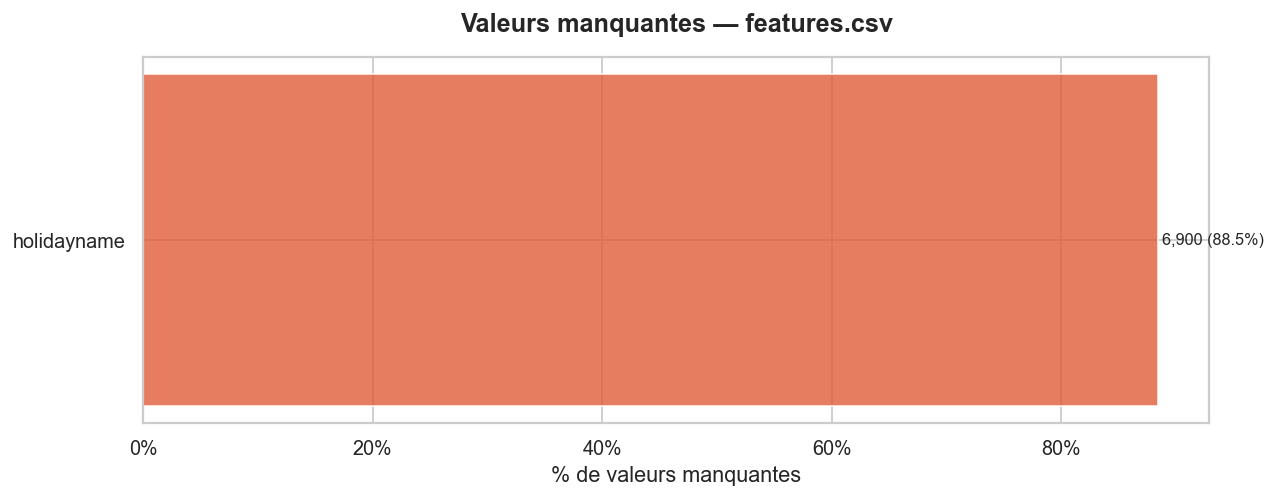


 Les MarkDowns sont absents avant Nov 2011 — comportement attendu.


In [52]:
# Visualisation des NaN dans features.csv
missing_feat = features.isnull().sum()
missing_feat = missing_feat[missing_feat > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    missing_feat.index,
    missing_feat.values / len(features) * 100,
    color=COLOR_NEG,
    alpha=0.8,
    edgecolor="white",
)
for bar, val in zip(bars, missing_feat.values):
    pct = val / len(features) * 100
    ax.text(
        pct + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,} ({pct:.1f}%)",
        va="center",
        fontsize=9,
    )
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Valeurs manquantes — features.csv")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES, "00_missing_features.png"), dpi=150, bbox_inches="tight"
)
plt.show()

print("\n Les MarkDowns sont absents avant Nov 2011 — comportement attendu.")

---
## Jointures — Construction du dataset maître

In [53]:
# ── Préparation des dates ──────────────────────────────────
# Conversion des dates
sales["date"] = pd.to_datetime(sales["date"])
features["date"] = pd.to_datetime(features["date"])

print("Shape avant jointures :", sales.shape)

# ── Jointure 1 : sales LEFT JOIN stores ON Store ────────────
df = sales.merge(stores, on="storeid", how="left")
print(f"Après jointure × stores   : {df.shape}")
print("  → Colonnes ajoutées : Type, Size")

# ── Jointure 2 : × features ON [Store, Date] ────────────────
# (on garde celui de sales comme référence)
features_clean = features.drop(columns=["isholiday"])
df = df.merge(features_clean, on=["storeid", "date"], how="left")
print(f"Après jointure × features : {df.shape}")
print("  → Colonnes ajoutées : Temperature, Fuel_Price, MarkDown1-5, CPI, Unemployment")

# Vérification que toutes les lignes train sont conservées
assert len(df) == len(sales), "Perte de lignes lors de la jointure !"
print("\n Jointures validées — aucune perte de ligne")

Shape avant jointures : (156000, 5)
Après jointure × stores   : (156000, 8)
  → Colonnes ajoutées : Type, Size
Après jointure × features : (156000, 19)
  → Colonnes ajoutées : Temperature, Fuel_Price, MarkDown1-5, CPI, Unemployment

 Jointures validées — aucune perte de ligne


In [54]:
# Vérification des correspondances de clés
missing_stores = set(sales["storeid"]) - set(stores["storeid"])
missing_features = set(zip(sales["storeid"], sales["date"])) - set(
    zip(features["storeid"], features["date"])
)

print(f"Magasins manquants dans 'stores' : {missing_stores or 'Aucun'}")
print(
    f"Couples [Store, Date] manquants dans 'features' : {len(missing_features) if missing_features else 'Aucun'}"
)
display(df.head(3))

Magasins manquants dans 'stores' : Aucun
Couples [Store, Date] manquants dans 'features' : Aucun


,storeid,deptid,date,weeklysales,isholiday,storetype,storesize,region,temperature,fuelprice,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,holidayname,season
0,1,1,2022-01-01,119075.96,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter
1,1,2,2022-01-01,119107.85,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter
2,1,3,2022-01-01,84369.88,1,A,213810,North,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter


---
## Feature Engineering

In [59]:
df = df.copy()

# ── Variables temporelles ─────────────────────────────────
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week.astype(int)
df["quarter"] = df["date"].dt.quarter
df["monthname"] = df["date"].dt.strftime("%B")
df["dayname"] = df["date"].dt.strftime("%A")

# ── Catégorisation taille magasin ─────────────────────────
df["sizecategory"] = pd.cut(
    df["storesize"],
    bins=[0, 80_000, 150_000, 999_999],
    labels=["Small", "Medium", "Large"],
)

# ── MarkDowns — traitement des NaN et négatifs ────────────
md_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
for col in md_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).clip(lower=0)

md_cols = ["markdown1", "markdown2", "markdown3", "markdown4", "markdown5"]
df["totalmarkdown"] = df[md_cols].sum(axis=1)
df["hasmarkdown"] = (df["Total_MarkDown"] > 0).astype(int)
df["markdownsegment"] = pd.cut(
    df["totalmarkdown"],
    bins=[-1, 0, 5_000, 20_000, 50_000, float("inf")],
    labels=[
        "Aucune promo",
        "Promo faible",
        "Promo modérée",
        "Promo forte",
        "Promo très forte",
    ],
)

# ── Weekly_Sales — clip des négatifs ─────────────────────
n_neg = (df["weeklysales"] < 0).sum()
df["weeklysalesclean"] = df["weeklysales"].clip(lower=0)
print(
    f"  Ventes négatives remplacées par 0 : {n_neg:,} lignes ({n_neg / len(df) * 100:.2f}%)"
)

# ── Labels ───────────────────────────────────────────────
df["holidaylabel"] = np.where(df["isholiday"], "Semaine fériée", "Semaine normale")
df["storelabel"] = "Store_" + df["storeid"].astype(str).str.zfill(2)
df["deptlabel"] = "Dept_" + df["deptid"].astype(str).str.zfill(2)

print(f"\n Feature engineering terminé")
print(f"   Dataset final : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Plage dates   : {df['date'].min().date()} → {df['date'].max().date()}")

  Ventes négatives remplacées par 0 : 0 lignes (0.00%)

 Feature engineering terminé
   Dataset final : 156,000 lignes × 43 colonnes
   Plage dates   : 2022-01-01 → 2024-12-21


---
## Aperçu du dataset maître

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 43 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   storeid           156000 non-null  int64         
 1   deptid            156000 non-null  int64         
 2   date              156000 non-null  datetime64[ns]
 3   weeklysales       156000 non-null  float64       
 4   isholiday         156000 non-null  int64         
 5   storetype         156000 non-null  object        
 6   storesize         156000 non-null  int64         
 7   region            156000 non-null  object        
 8   temperature       156000 non-null  float64       
 9   fuelprice         156000 non-null  float64       
 10  markdown1         156000 non-null  float64       
 11  markdown2         156000 non-null  float64       
 12  markdown3         156000 non-null  float64       
 13  markdown4         156000 non-null  float64       
 14  mark

In [62]:
print("KPI GLOBAUX")
print(f"  CA total      : {df['weeklysalesclean'].sum():>15,.0f} €")
print(f"  CA moyen/sem  : {df['weeklysalesclean'].mean():>15,.2f} €")
print(f"  Nb stores     : {df['storeid'].nunique():>15}")
print(f"  Nb depts      : {df['deptid'].nunique():>15}")
print(f"  Semaines      : {df['date'].nunique():>15}")
print(f"  Types stores  : {sorted(df['storetype'].unique())}")

display(
    df[
        [
            "storeid",
            "storelabel",
            "deptid",
            "date",
            "weeklysalesclean",
            "storetype",
            "sizecategory",
            "isholiday",
            "totalmarkdown",
            "markdownsegment",
            "year",
            "month",
            "quarter",
        ]
    ].head(5)
)

KPI GLOBAUX
  CA total      :   8,814,544,253 €
  CA moyen/sem  :       56,503.49 €
  Nb stores     :              50
  Nb depts      :              20
  Semaines      :             156
  Types stores  : ['A', 'B', 'C']


,storeid,storelabel,deptid,date,weeklysalesclean,storetype,sizecategory,isholiday,totalmarkdown,markdownsegment,year,month,quarter
0,1,Store_01,1,2022-01-01,119075.96,A,Large,1,29476.38,Promo forte,2022,1,1
1,1,Store_01,2,2022-01-01,119107.85,A,Large,1,29476.38,Promo forte,2022,1,1
2,1,Store_01,3,2022-01-01,84369.88,A,Large,1,29476.38,Promo forte,2022,1,1
3,1,Store_01,4,2022-01-01,88445.24,A,Large,1,29476.38,Promo forte,2022,1,1
4,1,Store_01,5,2022-01-01,65159.85,A,Large,1,29476.38,Promo forte,2022,1,1


---
## Construction du schéma en étoile

In [92]:
# FACT_SALES
fact_sales = df[["storeid", "deptid", "date", "weeklysalesclean", "isholiday"]].copy()

# DIM_DATE
dim_date = (
    df[
        [
            "date",
            "year",
            "month",
            "monthname",
            "week",
            "quarter",
            "isholiday",
            "holidaylabel",
            "season",
            "holidayname",
        ]
    ]
    .drop_duplicates("date")
    .sort_values("date")
    .reset_index(drop=True)
)

# DIM_STORE
dim_store = (
    df[["storeid", "storelabel", "storetype", "storesize", "sizecategory", "region"]]
    .drop_duplicates("storeid")
    .sort_values("storeid")
    .reset_index(drop=True)
)

# DIM_DEPT
dim_dept = (
    df[["deptid", "deptlabel"]]
    .drop_duplicates("deptid")
    .sort_values("deptid")
    .reset_index(drop=True)
)

#  DIM_MARKDOWN
md_cols_all = (
    ["storeid", "date"] + md_cols + ["totalmarkdown", "hasmarkdown", "markdownsegment"]
)
md_cols_present = [c for c in md_cols_all if c in df.columns]
dim_markdown = df[md_cols_present].drop_duplicates(["storeid", "date"]).copy()


#  Export CSV
tables = {
    "factsales": fact_sales,
    "dimdate": dim_date,
    "dimstore": dim_store,
    "dimdept": dim_dept,
    "dimmarkdown": dim_markdown,
}

print("\n EXPORT SCHÉMA EN ÉTOILE ")
for name, tbl in tables.items():
    path = os.path.join(STAR, f"{name}.csv")
    tbl.to_csv(path, index=False)
    print(f" {name:<18} {tbl.shape[0]:>10,} lignes × {tbl.shape[1]:>2} col. → {path}")


 EXPORT SCHÉMA EN ÉTOILE 
 factsales             156,000 lignes ×  5 col. → ../data/star_schema/factsales.csv
 dimdate                   156 lignes × 10 col. → ../data/star_schema/dimdate.csv
 dimstore                   50 lignes ×  6 col. → ../data/star_schema/dimstore.csv
 dimdept                    20 lignes ×  2 col. → ../data/star_schema/dimdept.csv
 dimmarkdown             7,800 lignes × 10 col. → ../data/star_schema/dimmarkdown.csv


In [88]:
# Validation des clés étrangères
print(" VALIDATION DES CLÉS ÉTRANGÈRES ")
stores_fact = set(fact_sales["storeid"].unique())
stores_dim = set(dim_store["storeid"].unique())
depts_fact = set(fact_sales["deptid"].unique())
depts_dim = set(dim_dept["deptid"].unique())
dates_fact = set(fact_sales["date"].astype(str).unique())
dates_dim = set(dim_date["date"].astype(str).unique())

print(f"  Store_ID orphelins (fact vs dim)  : {stores_fact - stores_dim or 'Aucun'}")
print(f"  Dept_ID orphelins  (fact vs dim)  : {depts_fact - depts_dim or 'Aucun'}")
print(f"  Dates orphelines   (fact vs dim)  : {len(dates_fact - dates_dim)} date(s)")

 VALIDATION DES CLÉS ÉTRANGÈRES 
  Store_ID orphelins (fact vs dim)  : Aucun
  Dept_ID orphelins  (fact vs dim)  : Aucun
  Dates orphelines   (fact vs dim)  : 0 date(s)


---
## Chargement en base postgrSQL

In [93]:
# psql toolkit
import psycopg2
from sqlalchemy import create_engine

user = "postgres"  # ou ton utilisateur défini dans le docker-compose
password = "postgres"  # idem
host = "localhost"
port = "5432"
database = "retailstore_db"

# Création de l'engine SQLAlchemy
engine = create_engine(f"postgresql://{user}:{password}@{host}:{port}/{database}")
try:
    engine
    print("Connection Successed to PSQL")
except:
    print("Unable to connect")

Connection Successed to PSQL


In [94]:
print("CHARGEMENT EN BASE POSTGRESQL")
for name, tbl in tables.items():
    # method="multi" accélère fortement le chargement dans PostgreSQL
    tbl.to_sql(name, engine, if_exists="replace", index=False, method="multi")
    print(f" {name:<18} {len(tbl):>10,} lignes chargées")

print("\n Base PostgreSQL mise à jour !")

CHARGEMENT EN BASE POSTGRESQL
 factsales             156,000 lignes chargées
 dimdate                   156 lignes chargées
 dimstore                   50 lignes chargées
 dimdept                    20 lignes chargées
 dimmarkdown             7,800 lignes chargées

 Base PostgreSQL mise à jour !


In [ ]:
# Si la table a été créée avec des majuscules, utilise des doubles guillemets
query = """
SELECT *
FROM dimstore;
"""
result = pd.read_sql_query(query, engine)
print("Requête SQL de test PostgreSQL :")
display(result)

---
## Visualisation rapide — Distribution du CA par type de store

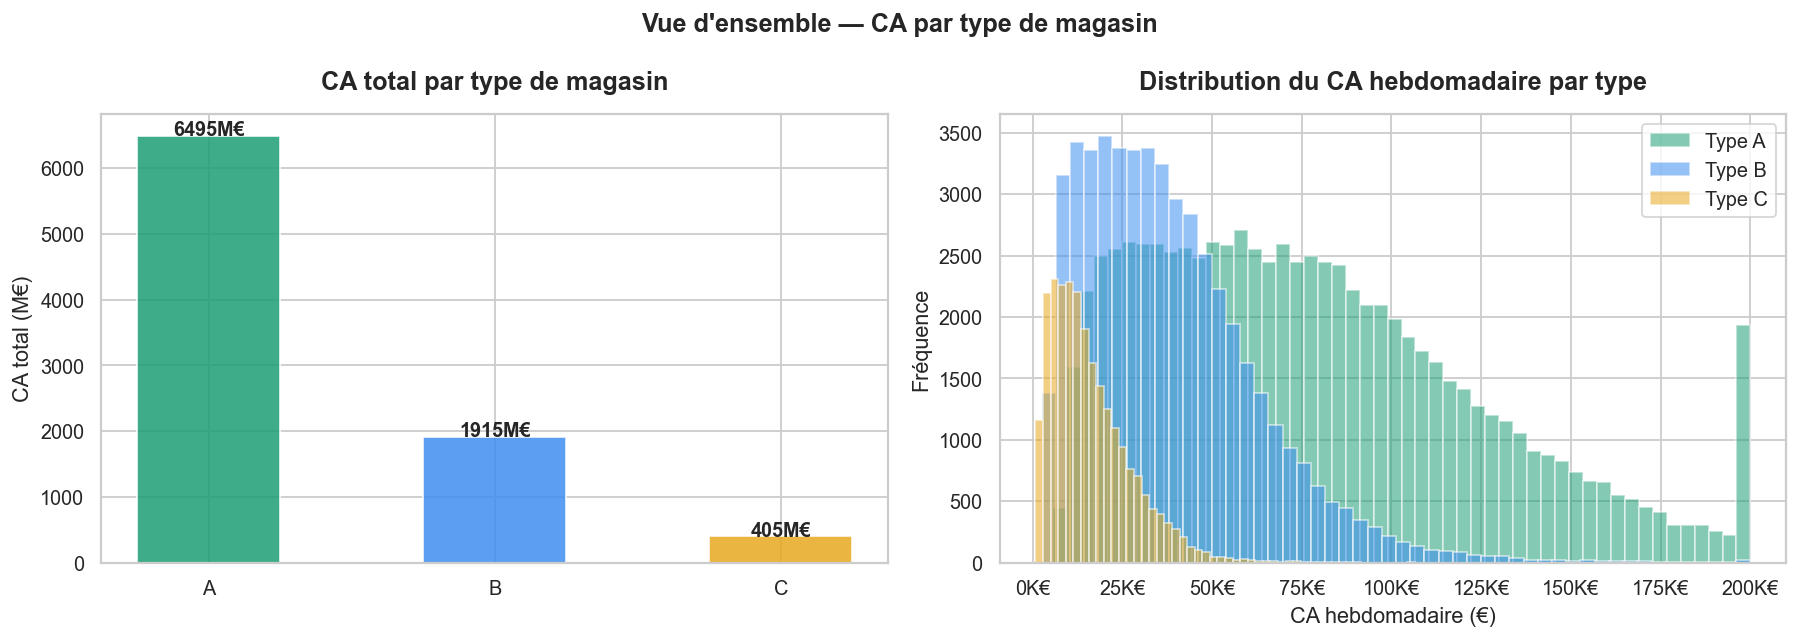

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CA total par type
ca_type = (
    df.groupby("storetype")["weeklysalesclean"]
    .agg(["sum", "mean"])
    .reset_index()
    .sort_values("sum", ascending=False)
)

colors = [COLOR_A, COLOR_B, COLOR_C][: len(ca_type)]
bars = axes[0].bar(
    ca_type["storetype"],
    ca_type["sum"] / 1e6,
    color=colors,
    alpha=0.85,
    edgecolor="white",
    width=0.5,
)
for bar, val in zip(bars, ca_type["sum"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val / 1e6:.0f}M€",
        ha="center",
        fontsize=11,
        fontweight="bold",
    )
axes[0].set_title("CA total par type de magasin")
axes[0].set_ylabel("CA total (M€)")

# Distribution Weekly_Sales par type
for i, (t, color) in enumerate(zip(sorted(df["storetype"].unique()), colors)):
    subset = df[df["storetype"] == t]["weeklysalesclean"].clip(0, 200_000)
    axes[1].hist(
        subset, bins=50, alpha=0.55, color=color, label=f"Type {t}", edgecolor="white"
    )
axes[1].set_title("Distribution du CA hebdomadaire par type")
axes[1].set_xlabel("CA hebdomadaire (€)")
axes[1].set_ylabel("Fréquence")
axes[1].xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f"{int(x / 1000)}K€")
)
axes[1].legend()

plt.suptitle("Vue d'ensemble — CA par type de magasin", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, "01_ca_par_type.png"), dpi=150, bbox_inches="tight")
plt.show()

---
## Sauvegarde du dataset maître

In [95]:
PROCESSED = os.path.join("..", "data", "processed")
os.makedirs(PROCESSED, exist_ok=True)

# Convertir les Categorical en string avant export
df_export = df.copy()
for col in df_export.select_dtypes(include="category").columns:
    df_export[col] = df_export[col].astype(str)

master_path = os.path.join(PROCESSED, "retail_master.csv")
df_export.to_csv(master_path, index=False)

print("   PARTIE 1 TERMINÉE")
print(f"   Dataset maître  : {master_path}")
print(f"   Dimensions      : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"   Base PostgrSQL     : {DB_PATH}")
print(f"   Tables étoile   : {STAR}")
print(f"   Graphiques      : {FIGURES}")
print("\n Prochaine étape : Partie 2 — EDA & Analyse des leviers")

   PARTIE 1 TERMINÉE
   Dataset maître  : ../data/processed/retail_master.csv
   Dimensions      : 156,000 lignes × 43 colonnes
   Base PostgrSQL     : ../data/processed/retail.db
   Tables étoile   : ../data/star_schema
   Graphiques      : ../outputs/figures

 Prochaine étape : Partie 2 — EDA & Analyse des leviers
